In [ ]:
# dataset used:
# https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

NUMBER_OF_BATCHES = 2 # Number of batches to use for training and validation datasets (-1 to use all batches)

In [49]:
!pip install --upgrade tensorflow
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages/",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages/",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

if NUMBER_OF_BATCHES > 0:
    train_dataset = train_dataset.take(NUMBER_OF_BATCHES)
    val_dataset = val_dataset.take(NUMBER_OF_BATCHES)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [50]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
val_dataset = val_dataset.map(lambda x, y: (x / 255.0, y))

train_dataset = train_dataset.apply(tf.data.experimental.ignore_errors())
val_dataset = val_dataset.apply(tf.data.experimental.ignore_errors())

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

In [51]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained layers (VERY IMPORTANT)
base_model.trainable = False

In [52]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # helps prevent overfitting
    layers.Dense(1, activation='sigmoid')
])

In [53]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [54]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
      2/Unknown 4s 379ms/step - accuracy: 0.6484 - loss: 0.6757

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7344 - loss: 0.5655 - val_accuracy: 0.9531 - val_loss: 0.2544
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8906 - loss: 0.3267 - val_accuracy: 0.9531 - val_loss: 0.1506
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9844 - loss: 0.1298 - val_accuracy: 0.9375 - val_loss: 0.1583
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9688 - loss: 0.0808 - val_accuracy: 0.9375 - val_loss: 0.1215
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0206 - val_accuracy: 0.9375 - val_loss: 0.1197
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9688 - loss: 0.0655 - val_accuracy: 0.9375 - val_loss: 0.0894
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9688 - loss: 0.0325 - val_accuracy: 1.0000 - val_loss: 0.0399
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9844 - loss: 0.0493 - val_accuracy: 0.9375 - val_loss: 0.1723
Epoch 9/10
2/2 ━━━━━━━━━━━━

In [55]:
import numpy as np

mis_images = []
mis_labels = []
mis_preds = []

# Loop over validation dataset
for images, labels in val_dataset:
    preds = model.predict(images)
    
    preds = (preds > 0.5).astype(int)  # convert to 0/1
    
    for i in range(len(images)):
        if preds[i] != labels[i]:
            mis_images.append(images[i])
            mis_labels.append(labels[i])
            mis_preds.append(preds[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step


C:\Users\User\AppData\Local\Temp\ipykernel_37128\4146760599.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = int(mis_preds[i])


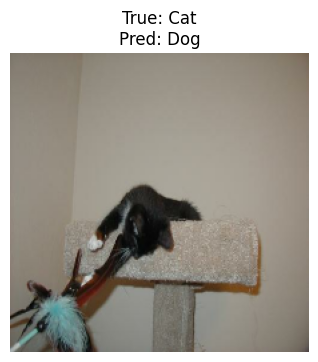

In [56]:
import matplotlib.pyplot as plt

class_names = ["Cat", "Dog"]

plt.figure(figsize=(10, 10))

for i in range(min(9, len(mis_images))):
    plt.subplot(3, 3, i + 1)
    
    img = mis_images[i].numpy()
    
    true_label = int(mis_labels[i])
    pred_label = int(mis_preds[i])
    
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    
    preds = (preds > 0.5).astype(int)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

# precision, recall, f1-score
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
[[33  2]
 [ 0 29]]
              precision    recall  f1-score   support

         Cat       1.00      0.94      0.97        35
         Dog       0.94      1.00      0.97        29

    accuracy                           0.97        64
   macro avg       0.97      0.97      0.97        64
weighted avg       0.97      0.97      0.97        64



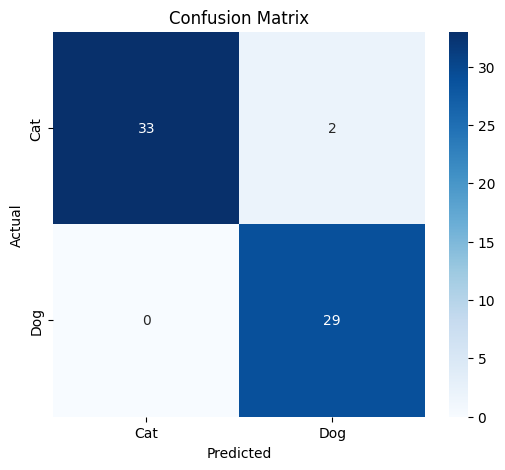

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["Cat", "Dog"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()